# **1. Install & Import Library**



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import joblib

print("TensorFlow version:", tf.__version__)
print("Semua library berhasil diimport!")

TensorFlow version: 2.20.0
Semua library berhasil diimport!


# **2. Load & Cek Data**

In [4]:
df = pd.read_csv('transaksi_bersih.csv')

print("Jumlah baris:", len(df))
print("Kolom:", df.columns.tolist())
print()
print("5 baris pertama:")
df.head()

Jumlah baris: 13486
Kolom: ['id_transaksi', 'id_warung', 'id_produk', 'tanggal', 'jam_transaksi', 'jenis', 'kategori', 'nominal', 'qty', 'metode_bayar', 'catatan', 'jenis_bersih', 'jam_missing', 'hari_dalam_minggu', 'nama_hari', 'bulan', 'minggu_ke', 'is_awal_bulan', 'is_weekend', 'jam_encoded']

5 baris pertama:


,id_transaksi,id_warung,id_produk,tanggal,jam_transaksi,jenis,kategori,nominal,qty,metode_bayar,catatan,jenis_bersih,jam_missing,hari_dalam_minggu,nama_hari,bulan,minggu_ke,is_awal_bulan,is_weekend,jam_encoded
0,329D1583-136,WRG-005,PRD-005-028,2026-07-01,1900-01-01 08:44:50,Pemasukan,Penjualan,27000.0,3.0,Cash,NaN,Pemasukan,0,2,Wednesday,2026-07,2026-06-29/2026-07-05,1,0,8.0
1,D0ECC4C8-9D6,WRG-005,PRD-005-013,2026-05-01,1900-01-01 20:11:25,Pemasukan,Penjualan,5000.0,1.0,Cash,NaN,Pemasukan,0,4,Friday,2026-05,2026-04-27/2026-05-03,1,0,20.0
2,714AE3C0-5DE,WRG-003,PRD-003-015,2026-10-01,1900-01-01 17:50:52,Pemasukan,Penjualan,5000.0,1.0,QRIS,NaN,Pemasukan,0,3,Thursday,2026-10,2026-09-28/2026-10-04,1,0,17.0
3,26088624-7A2,WRG-005,PRD-005-028,2026-03-02,1900-01-01 08:05:43,Pemasukan,Penjualan,9000.0,1.0,Transfer,NaN,Pemasukan,0,0,Monday,2026-03,2026-03-02/2026-03-08,1,0,8.0
4,55FF5DBF-A07,WRG-001,PRD-001-015,2026-06-02,1900-01-01 17:26:48,Pemasukan,Penjualan,22000.0,1.0,QRIS,NaN,Pemasukan,0,1,Tuesday,2026-06,2026-06-01/2026-06-07,1,0,17.0


# **3. Siapkan Data Time Series**

Jumlah hari: 694
Range tanggal: 2025-01-10 00:00:00 sampai 2026-12-04 00:00:00



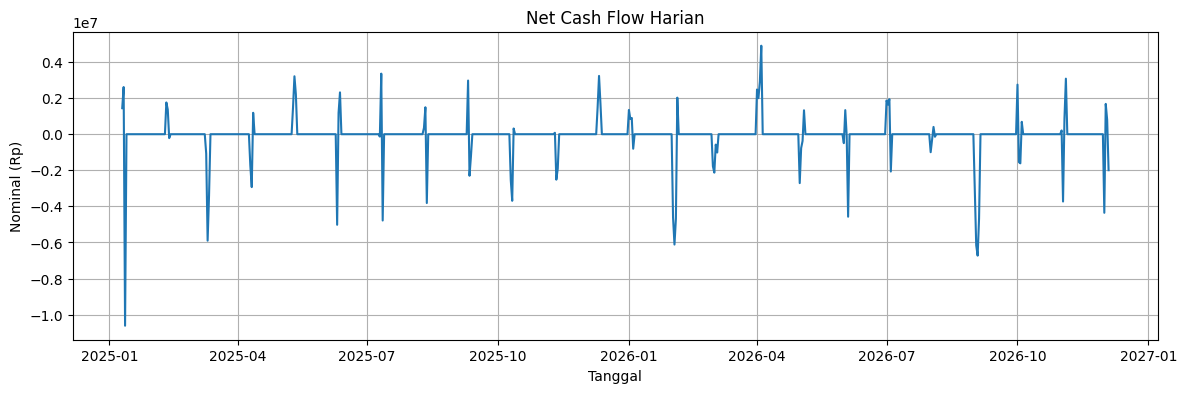

In [5]:
df['tanggal'] = pd.to_datetime(df['tanggal'])

pemasukan = df[df['jenis'] == 'Pemasukan'].groupby('tanggal')['nominal'].sum()
pengeluaran = df[df['jenis'] == 'Pengeluaran'].groupby('tanggal')['nominal'].sum()

daily = pd.DataFrame({
    'pemasukan': pemasukan,
    'pengeluaran': pengeluaran
}).fillna(0)

daily['net_cashflow'] = daily['pemasukan'] - daily['pengeluaran']
daily = daily.resample('D').sum().fillna(0)

print("Jumlah hari:", len(daily))
print("Range tanggal:", daily.index.min(), "sampai", daily.index.max())
print()

# Visualisasi
plt.figure(figsize=(14, 4))
plt.plot(daily['net_cashflow'])
plt.title('Net Cash Flow Harian')
plt.xlabel('Tanggal')
plt.ylabel('Nominal (Rp)')
plt.grid(True)
plt.show()

# **4. Scaling Data**

In [6]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(daily[['net_cashflow']])

print("Nilai sebelum scaling:", daily['net_cashflow'].min(), "sampai", daily['net_cashflow'].max())
print("Nilai setelah scaling:", scaled.min().round(4), "sampai", scaled.max().round(4))

# ── Buat sequences ────────────────────────────────────────────────────
# LSTM belajar dari pola: "kalau 30 hari sebelumnya seperti ini,
# maka hari berikutnya seperti ini"
LOOKBACK = 30  # model lihat 30 hari ke belakang untuk prediksi 1 hari ke depan

def buat_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])   # input: 30 hari sebelumnya
        y.append(data[i])              # target: hari ke-31
    return np.array(X), np.array(y)

X, y = buat_sequences(scaled, LOOKBACK)

# ── Split train & test ────────────────────────────────────────────────
# 80% untuk training, 20% untuk testing
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print()
print("Total sequences:", len(X))
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print()
print("Artinya:")
print(f"  - {X_train.shape[0]} sequences untuk training")
print(f"  - {X_test.shape[0]} sequences untuk testing")
print(f"  - Setiap sequence berisi {X_train.shape[1]} hari (lookback)")

Nilai sebelum scaling: -10615851.0 sampai 4904114.0
Nilai setelah scaling: 0.0 sampai 1.0

Total sequences: 664
X_train shape: (531, 30, 1)
X_test shape : (133, 30, 1)

Artinya:
  - 531 sequences untuk training
  - 133 sequences untuk testing
  - Setiap sequence berisi 30 hari (lookback)


# **5. Bangun Model LSTM dengan Functional API**

In [7]:
class BerhentiJikaMAECukup(keras.callbacks.Callback):
    """
    Callback custom: otomatis hentikan training kalau
    val_mae sudah di bawah threshold yang kita tentukan.
    Ini mencegah overfitting dan hemat waktu training.
    """
    def __init__(self, threshold=0.05):
        super().__init__()
        self.threshold = threshold
        self.epoch_terbaik = 0

    def on_epoch_end(self, epoch, logs=None):
        val_mae = logs.get('val_mae', 999)
        if val_mae < self.threshold:
            print(f"\n✓ Epoch {epoch+1}: val_mae={val_mae:.4f} sudah < {self.threshold}")
            print("  Training dihentikan otomatis oleh Custom Callback.")
            self.epoch_terbaik = epoch + 1
            self.model.stop_training = True

# BANGUN MODEL dengan Functional API (WAJIB MAIN QUEST)

# Langkah 1: Definisikan INPUT
inputs = keras.Input(shape=(LOOKBACK, 1), name='cashflow_input')

# Langkah 2: Tambahkan layer LSTM pertama
# return_sequences=True artinya output diteruskan ke LSTM berikutnya
x = layers.LSTM(64, return_sequences=True, name='lstm_1')(inputs)

# Langkah 3: Dropout — matikan 20% neuron secara acak saat training
# untuk mencegah model terlalu hafal data (overfitting)
x = layers.Dropout(0.2, name='dropout_1')(x)

# Langkah 4: LSTM kedua
# return_sequences=False karena ini layer LSTM terakhir
x = layers.LSTM(32, return_sequences=False, name='lstm_2')(x)

# Langkah 5: Dropout kedua
x = layers.Dropout(0.2, name='dropout_2')(x)

# Langkah 6: Dense layer untuk "memproses" hasil LSTM
x = layers.Dense(16, activation='relu', name='dense_1')(x)

# Langkah 7: Output layer — prediksi 1 nilai (cash flow besok)
outputs = layers.Dense(1, name='output')(x)

# Langkah 8: Satukan jadi model
model = keras.Model(inputs=inputs, outputs=outputs, name='CashFlowLSTM')

# COMPILE MODEL
model.compile(
    optimizer='adam',     # algoritma optimasi yang populer dan handal
    loss='mse',           # Mean Squared Error — fungsi loss untuk regresi
    metrics=['mae']       # Mean Absolute Error — metrik yang kita pantau
)

# Tampilkan ringkasan arsitektur model
model.summary()

Model: "CashFlowLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cashflow_input (InputLayer)     │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

# **6. Training Model**

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[
        BerhentiJikaMAECukup(threshold=0.05),
        keras.callbacks.ModelCheckpoint(
            'models/cashflow_lstm.keras',
            save_best_only=True,
            monitor='val_mae',
            verbose=1
        ),
        keras.callbacks.TensorBoard(log_dir='./tb_logs')
    ],
    verbose=1
)

print("\n✓ Training selesai!")

Epoch 1/100
33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1561 - mae: 0.3311
Epoch 1: val_mae improved from None to 0.06063, saving model to models/cashflow_lstm.keras

Epoch 1: finished saving model to models/cashflow_lstm.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0721 - mae: 0.2067 - val_loss: 0.0084 - val_mae: 0.0606
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0145 - mae: 0.0947
Epoch 2: val_mae did not improve from 0.06063
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0125 - mae: 0.0875 - val_loss: 0.0069 - val_mae: 0.0624
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0086 - mae: 0.0718
✓ Epoch 3: val_mae=0.0307 sudah < 0.05
  Training dihentikan otomatis oleh Custom Callback.

Epoch 3: val_mae improved from 0.06063 to 0.03070, saving model to models/cashflow_lstm.keras

Epoch 3: finished saving model to models/cashflow_lstm.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0095 - mae: 0.0738 - val_loss: 0.0057 - val_mae: 0

# **7. Evaluasi Model + Visualisasi**

HASIL EVALUASI MODEL
  Loss (MSE) : 0.005745
  MAE        : 0.030701
  Target MAE : 0.05
  Status     : ✓ LULUS


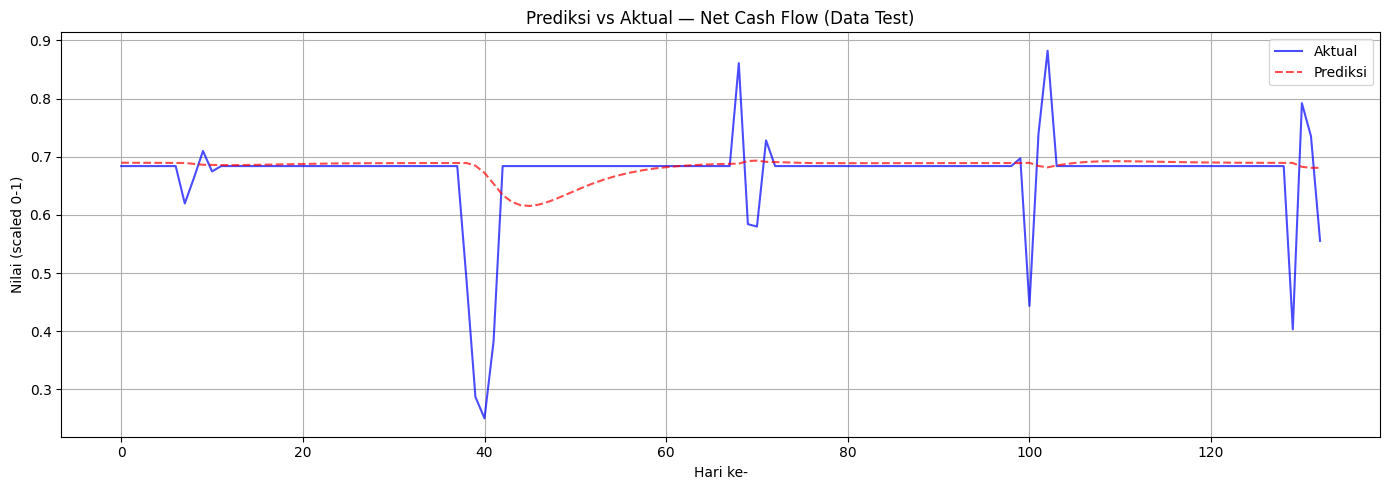


File tersimpan:
  ✓ models/cashflow_lstm.keras  (sudah disimpan saat training)
  ✓ models/scaler.pkl           (baru saja disimpan)

Silakan download kedua file ini dari panel Files di kiri!


In [9]:
# ── Evaluasi di data test ─────────────────────────────────────────────
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("=" * 45)
print("HASIL EVALUASI MODEL")
print("=" * 45)
print(f"  Loss (MSE) : {loss:.6f}")
print(f"  MAE        : {mae:.6f}")
print(f"  Target MAE : 0.05")
print(f"  Status     : {'✓ LULUS' if mae < 0.05 else '✗ Belum lulus'}")
print("=" * 45)

# ── Visualisasi: prediksi vs aktual ──────────────────────────────────
y_pred = model.predict(X_test, verbose=0)

plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Aktual', color='blue', alpha=0.7)
plt.plot(y_pred, label='Prediksi', color='red', alpha=0.7, linestyle='--')
plt.title('Prediksi vs Aktual — Net Cash Flow (Data Test)')
plt.xlabel('Hari ke-')
plt.ylabel('Nilai (scaled 0-1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Simpan scaler ─────────────────────────────────────────────────────
import os
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')

print("\nFile tersimpan:")
print("  ✓ models/cashflow_lstm.keras  (sudah disimpan saat training)")
print("  ✓ models/scaler.pkl           (baru saja disimpan)")
print("\nSilakan download kedua file ini dari panel Files di kiri!")

# **6b. Retrain Model**

In [10]:
# Reset model dari awal supaya bersih
keras.backend.clear_session()

# ── Bangun ulang model (sama persis) ─────────────────────────────────
inputs = keras.Input(shape=(LOOKBACK, 1), name='cashflow_input')
x = layers.LSTM(64, return_sequences=True, name='lstm_1')(inputs)
x = layers.Dropout(0.2, name='dropout_1')(x)
x = layers.LSTM(32, return_sequences=False, name='lstm_2')(x)
x = layers.Dropout(0.2, name='dropout_2')(x)
x = layers.Dense(16, activation='relu', name='dense_1')(x)
outputs = layers.Dense(1, name='output')(x)
model = keras.Model(inputs, outputs, name='CashFlowLSTM')
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ── Custom Callback yang lebih ketat ─────────────────────────────────
class BerhentiJikaMAECukup(keras.callbacks.Callback):
    def __init__(self, threshold=0.03, min_epochs=20):
        super().__init__()
        self.threshold = threshold
        self.min_epochs = min_epochs  # minimal harus jalan berapa epoch

    def on_epoch_end(self, epoch, logs=None):
        val_mae = logs.get('val_mae', 999)
        # baru berhenti kalau sudah melewati min_epochs DAN MAE sudah bagus
        if epoch + 1 >= self.min_epochs and val_mae < self.threshold:
            print(f"\n✓ Epoch {epoch+1}: val_mae={val_mae:.4f} < {self.threshold}. Stop.")
            self.model.stop_training = True

# ── Training ulang ────────────────────────────────────────────────────
print("Mulai retrain...\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,        # naikkan batas maksimum
    batch_size=16,
    callbacks=[
        BerhentiJikaMAECukup(threshold=0.03, min_epochs=20),
        keras.callbacks.ModelCheckpoint(
            'models/cashflow_lstm.keras',
            save_best_only=True,
            monitor='val_mae',
            verbose=0      # supaya output lebih bersih
        ),
        keras.callbacks.TensorBoard(log_dir='./tb_logs')
    ],
    verbose=1
)

print("\n✓ Retrain selesai!")

Mulai retrain...

Epoch 1/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0764 - mae: 0.2065 - val_loss: 0.0072 - val_mae: 0.0508
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0085 - mae: 0.0680 - val_loss: 0.0088 - val_mae: 0.0799
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0085 - mae: 0.0644 - val_loss: 0.0063 - val_mae: 0.0552
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0076 - mae: 0.0630 - val_loss: 0.0079 - val_mae: 0.0727
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0065 - mae: 0.0575 - val_loss: 0.0069 - val_mae: 0.0627
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0056 - mae: 0.0528 - val_loss: 0.0057 - val_mae: 0.0401
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064 - mae: 0.0567 - val_loss: 0.0077 - val_mae: 0.0718
Epoch 8/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0067 - mae: 0.0563 - val_loss: 0.0102 - val_mae: 0.0901
Epoch 9/150
34/34 ━━━━━━━━━━━━━━━━━━━━

# **8. Evaluasi Model Hasil Retrain**

HASIL EVALUASI MODEL (RETRAIN)
  Loss (MSE) : 0.005439
  MAE        : 0.027223
  Target MAE : 0.05
  Status     : ✓ LULUS


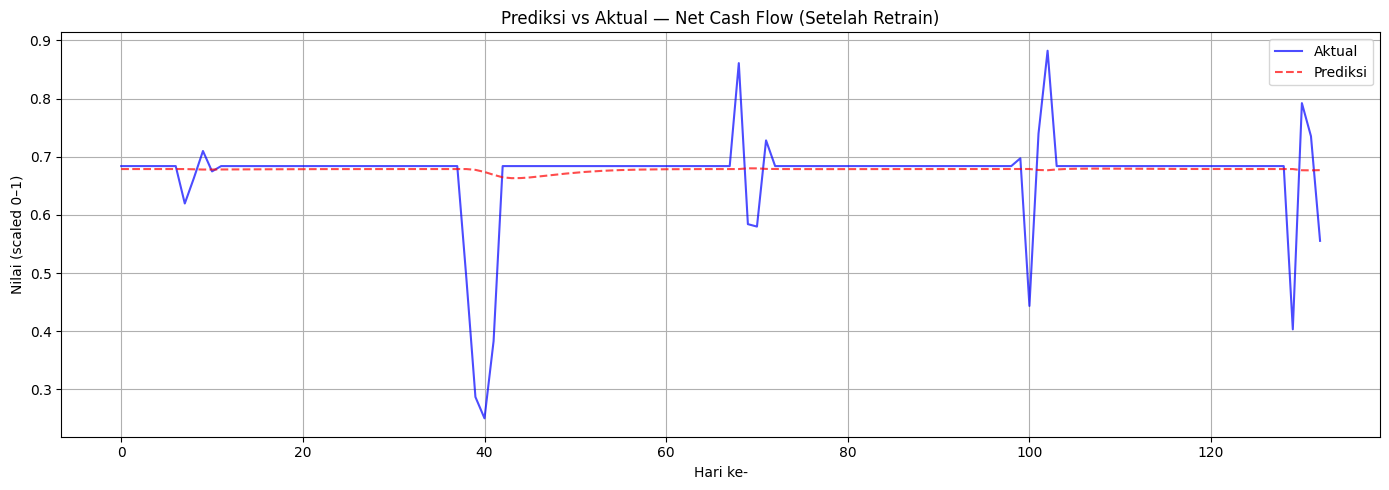


File final tersimpan:
  ✓ models/cashflow_lstm.keras
  ✓ models/scaler.pkl


In [11]:
# ── Evaluasi ──────────────────────────────────────────────────────────
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("=" * 45)
print("HASIL EVALUASI MODEL (RETRAIN)")
print("=" * 45)
print(f"  Loss (MSE) : {loss:.6f}")
print(f"  MAE        : {mae:.6f}")
print(f"  Target MAE : 0.05")
print(f"  Status     : {'✓ LULUS' if mae < 0.05 else '✗ Belum lulus'}")
print("=" * 45)

# ── Visualisasi prediksi vs aktual ────────────────────────────────────
y_pred = model.predict(X_test, verbose=0)

plt.figure(figsize=(14, 5))
plt.plot(y_test,  label='Aktual',   color='blue', alpha=0.7, linewidth=1.5)
plt.plot(y_pred,  label='Prediksi', color='red',  alpha=0.7, linewidth=1.5, linestyle='--')
plt.title('Prediksi vs Aktual — Net Cash Flow (Setelah Retrain)')
plt.xlabel('Hari ke-')
plt.ylabel('Nilai (scaled 0–1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Simpan ulang scaler (pastikan tersimpan) ──────────────────────────
import os
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')

print("\nFile final tersimpan:")
print("  ✓ models/cashflow_lstm.keras")
print("  ✓ models/scaler.pkl")